In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

RAW           = '../data/regular_lines_0728_0803.parquet'
DROP_THRESHOLD = 100  # same as detector.py

df = (
    pl.read_parquet(RAW, columns=['tst_iso', 'fzg_id', 'distanz', 'ort_nr_start_vvo', 'tuerkriterium'])
    .with_columns(pl.col('tst_iso').str.to_datetime(format='%Y-%m-%dT%H:%M:%S%.f%z'))
    .sort(['fzg_id', 'tst_iso'])
    .with_columns(pl.int_range(pl.len()).over('fzg_id').alias('row_idx'))
)
print(f'Rows: {len(df):,}  |  Vehicles: {df["fzg_id"].n_unique()}')
df.head(5)

Rows: 10,708,589  |  Vehicles: 534


tst_iso,fzg_id,distanz,ort_nr_start_vvo,tuerkriterium,row_idx
"datetime[μs, UTC]",i64,i64,str,bool,i64
2025-07-29 22:22:42.626209 UTC,6,0,"""-1""",false,0
2025-07-29 22:22:45.626898 UTC,6,0,"""-1""",false,1
2025-07-29 22:22:46.625247 UTC,6,0,"""-1""",false,2
2025-07-29 22:22:57.609258 UTC,6,0,"""-1""",false,3
2025-07-29 22:23:00.611140 UTC,6,0,"""-1""",false,4


## 1. Flag transitions

In [3]:
df = df.with_columns([
    pl.col('distanz').diff().over('fzg_id').alias('distanz_delta'),
    (
        pl.col('ort_nr_start_vvo') != pl.col('ort_nr_start_vvo').shift(1).over('fzg_id')
    ).alias('ort_changed'),
])

df = df.with_columns(
    (pl.col('distanz_delta') < -DROP_THRESHOLD).alias('distanz_drop')
).with_columns([
    # mask first row of each vehicle (shift artifact)
    pl.when(pl.col('row_idx') == 0).then(pl.lit(False)).otherwise(pl.col('ort_changed')).alias('ort_changed'),
    pl.when(pl.col('row_idx') == 0).then(pl.lit(False)).otherwise(pl.col('distanz_drop')).alias('distanz_drop'),
])

n_ort  = df['ort_changed'].sum()
n_drop = df['distanz_drop'].sum()
print(f'ort_nr_start_vvo changes : {n_ort:,}')
print(f'distanz drops (< -{DROP_THRESHOLD}m): {n_drop:,}')

ort_nr_start_vvo changes : 1,141,715
distanz drops (< -100m): 1,002,942


## 2. Same-row alignment

In [4]:
both      = (df['ort_changed'] & df['distanz_drop']).sum()
ort_only  = (df['ort_changed'] & ~df['distanz_drop']).sum()
drop_only = (~df['ort_changed'] & df['distanz_drop']).sum()

print('=== Same-row alignment ===')
print(f'  ort_changed AND distanz_drop  : {both:>8,}  ({both/n_ort*100:.1f}% of ort changes)')
print(f'  ort_changed, NO distanz_drop  : {ort_only:>8,}  ({ort_only/n_ort*100:.1f}%)')
print(f'  distanz_drop, NO ort_changed  : {drop_only:>8,}  ({drop_only/n_drop*100:.1f}% of drops)')

=== Same-row alignment ===
  ort_changed AND distanz_drop  :  984,136  (86.2% of ort changes)
  ort_changed, NO distanz_drop  :  157,579  (13.8%)
  distanz_drop, NO ort_changed  :    3,158  (0.3% of drops)


## 3. Lag analysis — does one lead the other by 1 row?

In [5]:
df = df.with_columns([
    pl.col('distanz_drop').shift(-1).over('fzg_id').alias('drop_lag_plus1'),   # drop 1 row AFTER ort change
    pl.col('distanz_drop').shift(1).over('fzg_id').alias('drop_lag_minus1'),   # drop 1 row BEFORE ort change
    pl.col('ort_changed').shift(-1).over('fzg_id').alias('ort_lag_plus1'),
    pl.col('ort_changed').shift(1).over('fzg_id').alias('ort_lag_minus1'),
])

ort_rows = df.filter(pl.col('ort_changed'))
total    = len(ort_rows)

at_minus1 = ort_rows['drop_lag_minus1'].sum()
at_0      = ort_rows['distanz_drop'].sum()
at_plus1  = ort_rows['drop_lag_plus1'].sum()

print('=== For each ort_changed row: where does distanz_drop fall? ===')
print(f'  lag -1 (drop came BEFORE ort change): {at_minus1:>7,}  ({at_minus1/total*100:.1f}%)')
print(f'  lag  0 (same row)                   : {at_0:>7,}  ({at_0/total*100:.1f}%)')
print(f'  lag +1 (drop comes AFTER ort change): {at_plus1:>7,}  ({at_plus1/total*100:.1f}%)')
print()
covered = (ort_rows['distanz_drop'] | ort_rows['drop_lag_minus1'] | ort_rows['drop_lag_plus1']).sum()
print(f'  ort changes with drop within ±1 row: {covered:>7,}  ({covered/total*100:.1f}%)')

=== For each ort_changed row: where does distanz_drop fall? ===
  lag -1 (drop came BEFORE ort change):  15,280  (1.3%)
  lag  0 (same row)                   : 984,136  (86.2%)
  lag +1 (drop comes AFTER ort change):  18,260  (1.6%)

  ort changes with drop within ±1 row: 1,013,425  (88.8%)


## 4. distanz value at the moment ort changes

=== distanz value at ort_nr_start_vvo change rows ===
  p0  :        0 m
  p5  :        0 m
  p10 :        0 m
  p25 :        4 m
  p50 :       15 m
  p75 :       15 m
  p90 :       39 m
  p95 :       90 m
  p99 :      487 m
  p100:    21240 m

  distanz <= 30m  : 1,011,915  (88.6%)
  distanz <= 100m : 1,088,956  (95.4%)


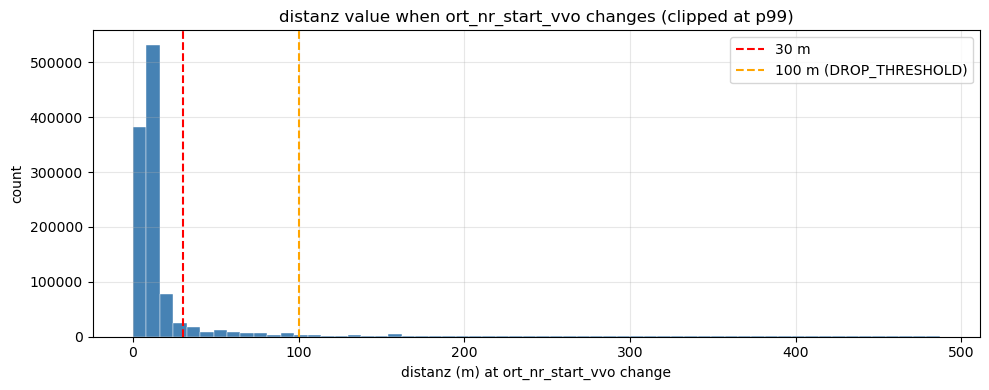

In [6]:
vals = ort_rows['distanz'].drop_nulls().to_numpy().astype(float)

print('=== distanz value at ort_nr_start_vvo change rows ===')
for p in [0, 5, 10, 25, 50, 75, 90, 95, 99, 100]:
    print(f'  p{p:<3d}: {np.percentile(vals, p):>8.0f} m')
print()
print(f'  distanz <= 30m  : {(vals <= 30).sum():,}  ({(vals <= 30).mean()*100:.1f}%)')
print(f'  distanz <= 100m : {(vals <= 100).sum():,}  ({(vals <= 100).mean()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(10, 4))
clip = np.percentile(vals, 99)
ax.hist(vals[vals <= clip], bins=60, edgecolor='white', linewidth=0.3, color='steelblue')
ax.axvline(30,             color='red',    linestyle='--', linewidth=1.5, label='30 m')
ax.axvline(DROP_THRESHOLD, color='orange', linestyle='--', linewidth=1.5, label=f'{DROP_THRESHOLD} m (DROP_THRESHOLD)')
ax.set_xlabel('distanz (m) at ort_nr_start_vvo change')
ax.set_ylabel('count')
ax.set_title('distanz value when ort_nr_start_vvo changes (clipped at p99)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('quality_report/09_distanz_at_ort_change.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Cases where they do NOT align — what happens?

ort changed but NO distanz drop: 157,579
distanz_delta distribution in these rows:
  p0  :       -100 m
  p5  :        -95 m
  p25 :        -73 m
  p50 :         -7 m
  p75 :         13 m
  p95 :        532 m
  p100:      21034 m


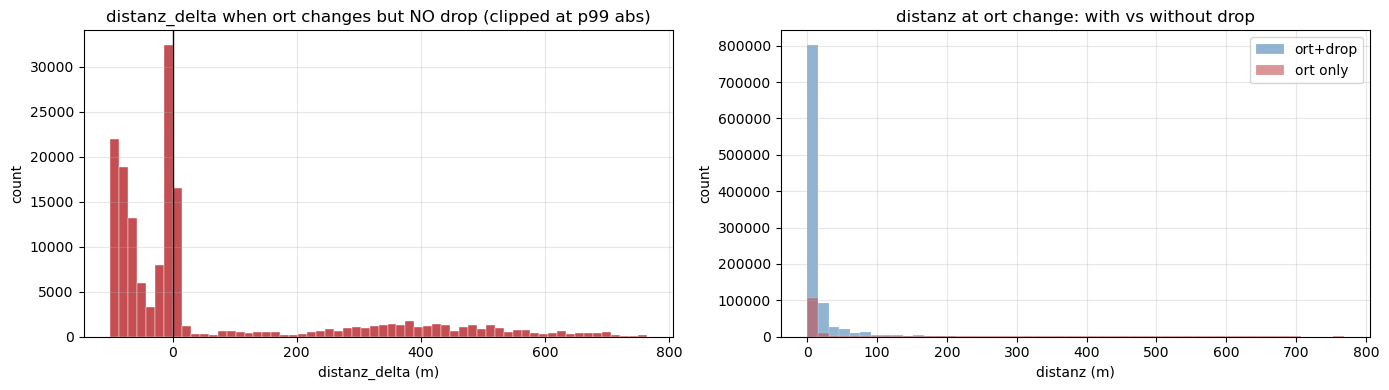

In [7]:
# ort changes but distanz does NOT drop — inspect distanz_delta distribution
ort_no_drop = ort_rows.filter(~pl.col('distanz_drop'))
delta_vals  = ort_no_drop['distanz_delta'].drop_nulls().to_numpy().astype(float)

print(f'ort changed but NO distanz drop: {len(ort_no_drop):,}')
print('distanz_delta distribution in these rows:')
for p in [0, 5, 25, 50, 75, 95, 100]:
    print(f'  p{p:<3d}: {np.percentile(delta_vals, p):>10.0f} m')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: delta distribution for ort-change-without-drop
clip = np.percentile(np.abs(delta_vals), 99)
axes[0].hist(delta_vals[np.abs(delta_vals) <= clip], bins=60, edgecolor='white', linewidth=0.3, color='#C44E52')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_xlabel('distanz_delta (m)')
axes[0].set_ylabel('count')
axes[0].set_title('distanz_delta when ort changes but NO drop (clipped at p99 abs)')
axes[0].grid(alpha=0.3)

# Right: comparison — drop rows vs ort-only rows (distanz value)
both_vals     = df.filter(pl.col('ort_changed') & pl.col('distanz_drop'))['distanz'].to_numpy().astype(float)
ort_only_vals = ort_no_drop['distanz'].to_numpy().astype(float)
clip2 = max(np.percentile(both_vals, 99), np.percentile(ort_only_vals, 99))
axes[1].hist(both_vals[both_vals <= clip2],     bins=50, alpha=0.6, label='ort+drop',  color='steelblue', edgecolor='white', linewidth=0.2)
axes[1].hist(ort_only_vals[ort_only_vals <= clip2], bins=50, alpha=0.6, label='ort only', color='#C44E52',   edgecolor='white', linewidth=0.2)
axes[1].set_xlabel('distanz (m)')
axes[1].set_ylabel('count')
axes[1].set_title('distanz at ort change: with vs without drop')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('quality_report/09_ort_no_drop.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Example traces

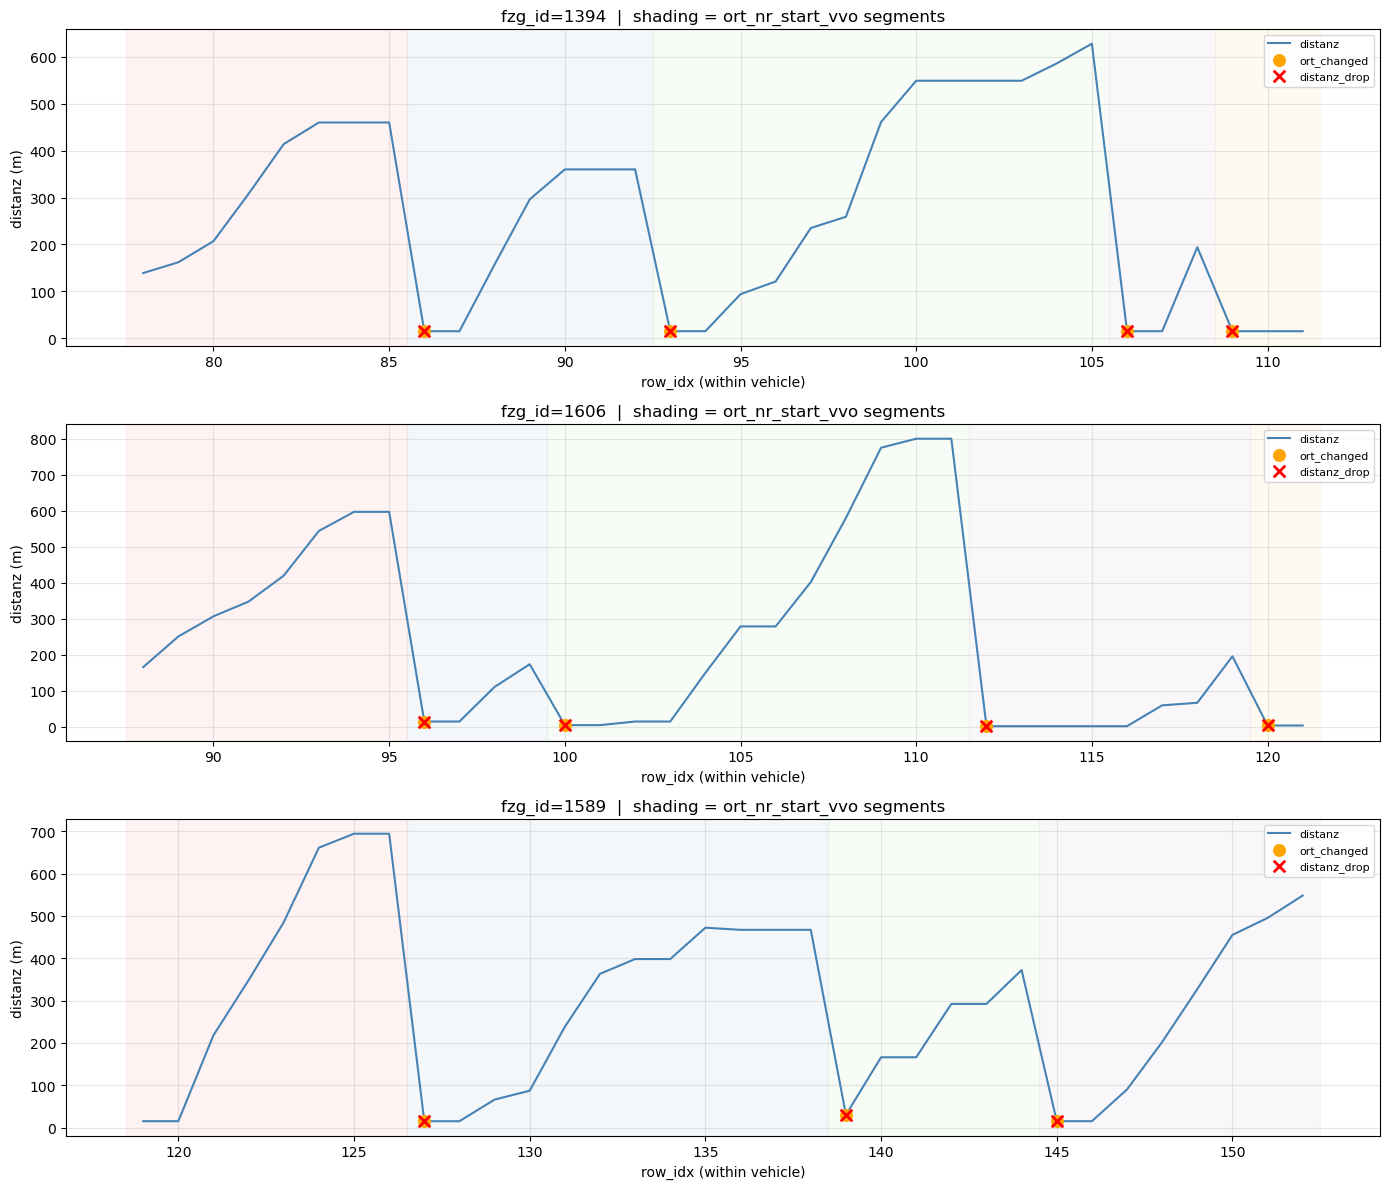

In [8]:
# Pick vehicles that have several ort changes
sample_vids = (
    df.filter(pl.col('ort_changed'))
    .group_by('fzg_id').len()
    .filter(pl.col('len') >= 10)
    .sample(3, seed=0)['fzg_id']
    .to_list()
)

fig, axes = plt.subplots(len(sample_vids), 1, figsize=(14, 4 * len(sample_vids)))
if len(sample_vids) == 1:
    axes = [axes]

colors_bg = plt.cm.Pastel1.colors

for ax, vid in zip(axes, sample_vids):
    v = df.filter(pl.col('fzg_id') == vid).sort('row_idx')
    # show a window around the 3rd ort change
    change_idxs = v.filter(pl.col('ort_changed'))['row_idx'].to_list()
    anchor = change_idxs[min(2, len(change_idxs) - 1)]
    win = v.filter(pl.col('row_idx').is_between(anchor - 8, anchor + 25))

    ridx    = win['row_idx'].to_numpy()
    distanz = win['distanz'].to_numpy().astype(float)
    ort_chg = win['ort_changed'].to_numpy()
    d_drop  = win['distanz_drop'].to_numpy()
    ort_seq = win['ort_nr_start_vvo'].to_numpy()

    ax.plot(ridx, distanz, color='steelblue', linewidth=1.5, label='distanz')
    ax.scatter(ridx[ort_chg], distanz[ort_chg], color='orange', zorder=5, s=70,
               label='ort_changed', marker='o')
    ax.scatter(ridx[d_drop],  distanz[d_drop],  color='red',    zorder=5, s=70,
               label='distanz_drop', marker='x', linewidths=2)

    # shade segments by ort_nr
    ci, prev_ort, prev_r = 0, ort_seq[0], ridx[0]
    for r, o in zip(ridx, ort_seq):
        if o != prev_ort:
            ax.axvspan(prev_r - 0.5, r - 0.5, alpha=0.15, color=colors_bg[ci % len(colors_bg)])
            ci += 1
            prev_ort, prev_r = o, r
    ax.axvspan(prev_r - 0.5, ridx[-1] + 0.5, alpha=0.15, color=colors_bg[ci % len(colors_bg)])

    ax.set_ylabel('distanz (m)')
    ax.set_xlabel('row_idx (within vehicle)')
    ax.set_title(f'fzg_id={vid}  |  shading = ort_nr_start_vvo segments')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('quality_report/09_example_traces.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Concrete examples of each alignment case

In [10]:
COLS    = ['fzg_id', 'row_idx', 'tst_iso', 'distanz', 'distanz_delta', 'ort_nr_start_vvo', 'tuerkriterium', 'ort_changed', 'distanz_drop']
WINDOW  = 3
SAMPLES = 5

def show_examples(df, event_mask, label, seed=42):
    events = df.filter(event_mask)
    sample = events.sample(min(SAMPLES, len(events)), seed=seed)
    print(f"\n{'='*70}")
    print(f"  {label}  (n={len(events):,})  — showing ±{WINDOW} rows around each event")
    print(f"{'='*70}")
    for row in sample.iter_rows(named=True):
        vid, ridx = row['fzg_id'], row['row_idx']
        ctx = (
            df.filter(pl.col('fzg_id') == vid)
              .filter(pl.col('row_idx').is_between(ridx - WINDOW, ridx + WINDOW))
              .sort('row_idx')
              .select(COLS)
              .with_columns(pl.col('tst_iso').dt.to_string('%H:%M:%S').alias('tst_iso'))
        )
        print(f"\n  fzg_id={vid}, event at row_idx={ridx}")
        print(ctx.to_pandas().to_string(index=False))

# Case 1: both signals fire on the same row  (86.2%)
show_examples(df,
    pl.col('ort_changed') & pl.col('distanz_drop'),
    "Case 1: ort_changed AND distanz_drop")

# Case 2: ort changes but distanz does NOT drop  (13.8%)
show_examples(df,
    pl.col('ort_changed') & ~pl.col('distanz_drop'),
    "Case 2: ort_changed, NO distanz_drop",
    seed=7)

# Case 3: distanz drops but ort does NOT change  (0.3%)
show_examples(df,
    ~pl.col('ort_changed') & pl.col('distanz_drop'),
    "Case 3: distanz_drop, NO ort_changed",
    seed=0)


  Case 1: ort_changed AND distanz_drop  (n=984,136)  — showing ±3 rows around each event

  fzg_id=2176, event at row_idx=22478
 fzg_id  row_idx  tst_iso  distanz  distanz_delta ort_nr_start_vvo  tuerkriterium  ort_changed  distanz_drop
   2176    22475 11:08:47      310             58          0917002          False        False         False
   2176    22476 11:08:50      310              0          0917002          False        False         False
   2176    22477 11:08:51      343             33          0917002          False        False         False
   2176    22478 11:08:57       15           -328          0939002          False         True          True
   2176    22479 11:09:12      130            115          0939002          False        False         False
   2176    22480 11:09:26      211             81          0939002          False        False         False
   2176    22481 11:09:42      231             20          0939002          False        False         False

## 8. ort change rate in no_door stop events

In [12]:
# Load stop events and check status distribution
se = pl.read_parquet('../data/processed/core_stop_events.parquet')
print('stop_status distribution:')
print(se.group_by('stop_status').len().rename({'len': 'count'}).sort('count', descending=True))

no_door_se = se.filter(pl.col('stop_status') == 'no_door')
print(f'\nno_door events: {len(no_door_se):,} / {len(se):,}  ({len(no_door_se)/len(se)*100:.1f}%)')

stop_status distribution:
shape: (3, 2)
┌─────────────┬────────┐
│ stop_status ┆ count  │
│ ---         ┆ ---    │
│ str         ┆ u32    │
╞═════════════╪════════╡
│ normal      ┆ 776517 │
│ no_door     ┆ 197504 │
│ multi_door  ┆ 2372   │
└─────────────┴────────┘

no_door events: 197,504 / 976,393  (20.2%)


In [13]:
# Join no_door stop events with raw df on (fzg_id, drop_row_idx) == (fzg_id, row_idx)
joined = no_door_se.join(
    df.select(['fzg_id', 'row_idx', 'ort_changed', 'ort_nr_start_vvo', 'distanz', 'distanz_delta', 'tuerkriterium']),
    left_on=['fzg_id', 'drop_row_idx'],
    right_on=['fzg_id', 'row_idx'],
    how='left'
)

n_total       = len(joined)
n_ort_changed = joined['ort_changed'].sum()
print('=== ort change rate in no_door stop events ===')
print(f'  ort_changed = True  : {n_ort_changed:>7,}  ({n_ort_changed/n_total*100:.1f}%)')
print(f'  ort_changed = False : {n_total-n_ort_changed:>7,}  ({(n_total-n_ort_changed)/n_total*100:.1f}%)')

# 5 examples
print('\n--- 5 examples (no_door stop events, ±3 raw rows around drop_row_idx) ---')
sample = joined.sample(5, seed=42)
for row in sample.iter_rows(named=True):
    vid, ridx = row['fzg_id'], row['drop_row_idx']
    ctx = (
        df.filter(pl.col('fzg_id') == vid)
          .filter(pl.col('row_idx').is_between(ridx - 3, ridx + 3))
          .sort('row_idx')
          .select(COLS)
          .with_columns(pl.col('tst_iso').dt.to_string('%H:%M:%S').alias('tst_iso'))
    )
    print(f'\n  fzg_id={vid}  drop_row_idx={ridx}  ort_changed={row["ort_changed"]}')
    print(ctx.to_pandas().to_string(index=False))

=== ort change rate in no_door stop events ===
  ort_changed = True  : 193,690  (98.1%)
  ort_changed = False :   3,814  (1.9%)

--- 5 examples (no_door stop events, ±3 raw rows around drop_row_idx) ---

  fzg_id=2321  drop_row_idx=15545  ort_changed=True
 fzg_id  row_idx  tst_iso  distanz  distanz_delta ort_nr_start_vvo  tuerkriterium  ort_changed  distanz_drop
   2321    15542 08:54:39      236            203          0662001          False        False         False
   2321    15543 08:54:52      413            177          0662001          False        False         False
   2321    15544 08:54:55      427             14          0662001          False        False         False
   2321    15545 08:54:56       46           -381          0619001          False         True          True
   2321    15546 08:54:58       46              0          0619001          False        False         False
   2321    15547 08:55:12      237            191          0619001          False        F